# Imports and constants

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [ ]:
# Simulation data folders
dirpath_sim = "/net/debye/gmennella/randium/sims"

# Data folders dict
dirpath_dict = {
    "hexagonal"  : f"{dirpath_sim}/sims_hexagonal",
    "triangular" : f"{dirpath_sim}/sims_triangular",
    "king"       : f"{dirpath_sim}/sims_king",
    "cubic"      : f"{dirpath_sim}/sims_cubic",
}

# This is to cover specifics naming convention 
naming_dict = {
    "hexagonal"  : "_v3_short",
    "triangular" : "_v3_short",
    "king"       : "_v3_short",
    "cubic"      : "_configB_L48",
}

# Output folders
outdirpath_fig = "/net/debye/gmennella/randium/analysis/analysis_figure"
outdirpath_data = "/net/debye/gmennella/randium/analysis/analysis_data"

# Relax time criterion
overlap_target = .5
tau_g_target = 10**5

In [3]:
# Plot params.
fontsize_label = 15
fontsize_title = 15
fontsize_legend = 12

# Markers and stuff
label_list = ["hex", "sq", "tri", "king", "cube"]

marker_list = ["h", "+", "^", "*", "s"]
color_list = ["red", "tab:blue", "green", "orange", "blue"]

# Functions

In [4]:
def get_data_filepath(beta, version, dimension=2, size=192, device='gpu'):
    """
    Build path to simulation data.
    """

    # Find folder name 
    master_dir = dirpath_dict[version]
    version_name = naming_dict[version]

    base_path = f"{master_dir}/runs{version_name}/Data"

    if dimension == 2:
        filepath = f"{base_path}/{device}_{size}x{size}beta{beta:1.4f}.csv"

    elif dimension == 3:
        filepath = f"{base_path}/{device}_{size}x{size}x{size}beta{beta:1.4f}.csv"

    return filepath

def get_tau_filepath(lattice, datapath=outdirpath_data):

    filepath = f"{datapath}/{lattice}_tau_vs_beta.dat"

    return filepath

def get_tau_fit_filepath(lattice, datapath=outdirpath_data):

    filepath = f"{datapath}/{lattice}_tau_fit.dat"

    return filepath

In [5]:
def get_tau_exp_trend_line(
    beta_list,
    A,
    tau0,
):
    tau_list = tau0 * np.exp(A * beta_list)

    return beta_list, tau_list

def get_tau_exp_trend_parabola(
    beta_list,
    J,
    beta_q,
    tau_q
):
    tau_list = tau_q * np.exp(
        J**2 * np.power(beta_list - beta_q, 2)
    )

    return beta_list, tau_list

# Data loading

## Square (ref)

In [6]:
# ===== Data (ref) =====
filepath_reference_time = "/net/debye/gmennella/randium/randium_versions/randium_original/data/t_halfs.csv"

data_reference = pd.read_csv(filepath_reference_time)

beta_ref_list = np.array(data_reference['beta'])
tau_ref_list = np.array(data_reference['t_half'])

# ===== Params (ref) =====
# Low-beta regime: line
tau0_ref = np.log(np.sqrt(2))
A_ref = 1.5

betaref_line_list, tau_ref_line_list = get_tau_exp_trend_line(
    beta_list=np.linspace(10**(-4), 1.0, num=10000),
    tau0=tau0_ref,
    A=A_ref
)

# High-beta regime: parabola
J_ref = 4.3
tau_q_ref = 50
beta_q_ref = 0.93

beta_list_parabola_ref, tau_list_parabola_ref = get_tau_exp_trend_parabola(
    beta_list=np.linspace(1.2, 1.9, num=10000),
    tau_q=tau_q_ref,
    J=J_ref,
    beta_q=beta_q_ref
)

# Reference beta_glass
beta_g_ref = 2.16

## My sims

In [7]:
lattice_list = [
    "hexagonal", "square", "triangular", "king", "cubic"
]

data_mat = [
    np.loadtxt(get_tau_filepath(lattice)).T
    for lattice in lattice_list
]

beta_mat = [data[0,:] for data in data_mat]
tau_mat = [data[1,:] for data in data_mat]

# Filter out nans
beta_filtered = []
tau_filtered = []

for beta_list, tau_list in zip(beta_mat, tau_mat):

    mask = ~np.isnan(tau_list)
    beta_filtered.append(beta_list[mask])
    tau_filtered.append(tau_list[mask])

beta_mat = beta_filtered
tau_mat = tau_filtered

## Plot

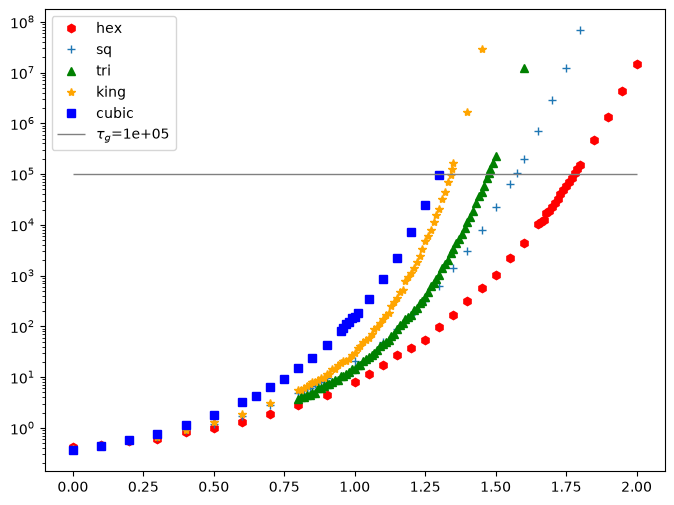

In [8]:
plt.figure(figsize=(8,6))

plot_label_list = ["hex", "sq", "tri", "king", "cubic"]

# ===== Data =====
for beta_list, tau_list, label, color, marker in zip(
    beta_mat, tau_mat,
    plot_label_list,
    color_list,
    marker_list,
    strict=True
):

    plt.plot(
        beta_list, tau_list,
        label=label,
        color=color,
        marker=marker,
        linestyle=''
    )

# ===== Target =====
plt.hlines(
    tau_g_target, xmin=0., xmax=2, 
    label=f'$\\tau_g$={10**5:.0e}',
    color='gray', 
    linewidth=1
)

plt.yscale("log")

plt.legend()

plt.savefig(
    f"{outdirpath_fig}/relaxation_time_vs_beta_all_lattice.png",
    dpi=300,
    bbox_inches="tight"
)

# Analysis - beta glass

In [9]:
def get_beta_glass(beta_list, tau_list, target=tau_g_target, tollerance=.1):

    # Look for beta_glass
    beta_idx = np.argmin(np.abs(tau_list - target))
    beta_glass = beta_list[beta_idx]
    tau_glass = tau_list[beta_idx]

    # Sanity check: prevent false positive.
    relative_log_error = np.log10(np.abs(tau_glass - target)) / target

    if relative_log_error <= tollerance:

        beta_idx = np.argmin(np.abs(tau_list - target))
        beta_glass = beta_list[beta_idx]
        tau_glass = tau_list[beta_idx]

        return beta_glass, tau_glass

    else:
        print("Warning, failed to check criteria!")
        print(f"beta_g = {beta_glass};")
        print(f"tau_g = {tau_glass};")
        print(tau_glass - target)
        print(f"log_error = {relative_log_error};")

        return None, None

In [10]:
beta_g_list = np.empty(len(tau_mat), dtype=float)
tau_g_list = np.empty(len(tau_mat), dtype=float)

for idx, (beta_list, tau_list, lattice) in enumerate(
    zip(beta_mat, tau_mat, label_list, strict=True)
):

    temp = get_beta_glass(beta_list, tau_list)
    beta_g_list[idx] = temp[0]
    tau_g_list[idx] = temp[1]
    print(f"Found: lattice={lattice}, beta_g={temp[0]}, tau_g={temp[1]:.2e}")

Found: lattice=hex, beta_g=1.78, tau_g=1.03e+05
Found: lattice=sq, beta_g=1.575, tau_g=1.03e+05
Found: lattice=tri, beta_g=1.475, tau_g=1.03e+05
Found: lattice=king, beta_g=1.34, tau_g=9.41e+04
Found: lattice=cube, beta_g=1.3, tau_g=9.41e+04


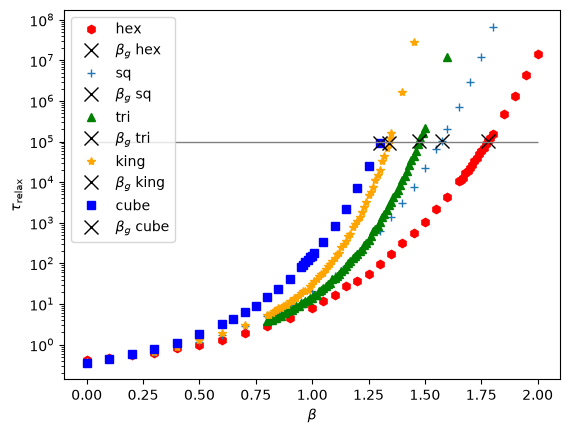

In [11]:
for beta_list, tau_list, beta_g, tau_g, label, color, marker in zip(
    beta_mat, tau_mat,
    beta_g_list, tau_g_list,
    label_list,
    color_list,
    marker_list,
    strict=False
):

    plt.plot(
        beta_list, tau_list,
        label=label,
        color=color,
        marker=marker,
        linestyle=''
    )

    plt.plot(
        beta_g, tau_g, 
        label=f'$\\beta_g$ {label}', 
        color='black', 
        marker='x',
        markersize=10,
        linestyle=''
    )

plt.hlines(tau_g_target, xmin=0., xmax=2., color='gray', linewidth=1)

plt.yscale("log")

plt.xlabel("$\\beta$")
plt.ylabel("$\\tau_{\\text{relax}}$")
plt.legend()

## Plot - Rescaled relaxation time

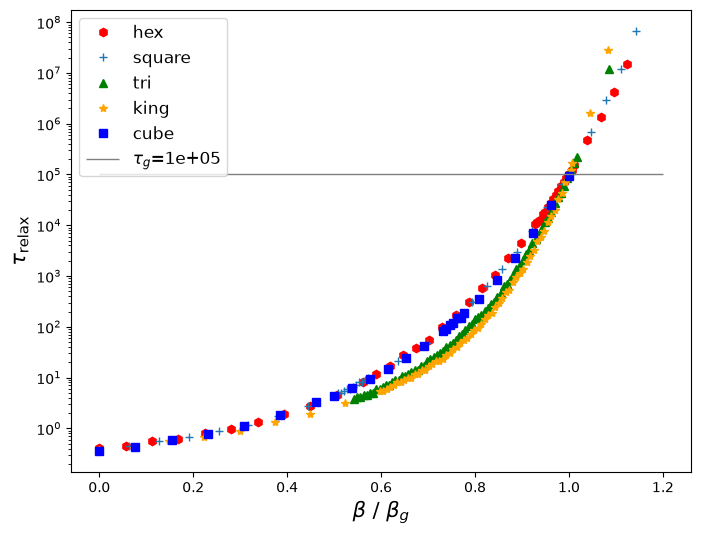

In [12]:
plot_label_list = [
    "hex", "square", "tri", "king", "cube"
]

plt.figure(figsize=(8,6))

for beta_list, tau_list, beta_g, label, color, marker in zip(
    beta_mat, tau_mat,
    beta_g_list,
    plot_label_list,
    color_list,
    marker_list,
    strict=False
):

    plt.plot(
        beta_list / beta_g, tau_list,
        label=label,
        color=color,
        marker=marker,
        linestyle=''
    )

plt.hlines(
    tau_g_target, xmin=0., xmax=1.2, 
    label=f'$\\tau_g$={10**5:.0e}',
    color='gray', 
    linewidth=1
)

plt.yscale("log")

plt.xlabel("$\\beta$ / $\\beta_g$", fontsize=fontsize_label)
plt.ylabel("$\\tau_{\\text{relax}}$", fontsize=fontsize_label)
# plt.title(
#     "Relaxation time vs rescaled inverse temperature ",
#     fontsize=fontsize_title
# )
plt.legend(fontsize=fontsize_legend)

plt.savefig(
    f"{outdirpath_fig}/relaxation_time_vs_rescaled_beta_all_lattice.png",
    dpi=300,
    bbox_inches="tight"
)

# Fit results

In [13]:
fit_lattice_list = [
    "hexagonal", "square", "triangular", "king", "cubic"
]

cardinality_list = [
    3, 4, 6, 8, 6
]

tau_fit_mat = np.array([
    np.loadtxt(get_tau_fit_filepath(lattice))
    for lattice in fit_lattice_list
])

# Param mats shape: (2, lattice_num)
# 1st row=estimation, 2nd row=std
J_mat = tau_fit_mat[:, 0, :]
beta_q_mat = tau_fit_mat[:, 1, :]
tau_q_mat = tau_fit_mat[:, 2, :]

## Plot - Fit results

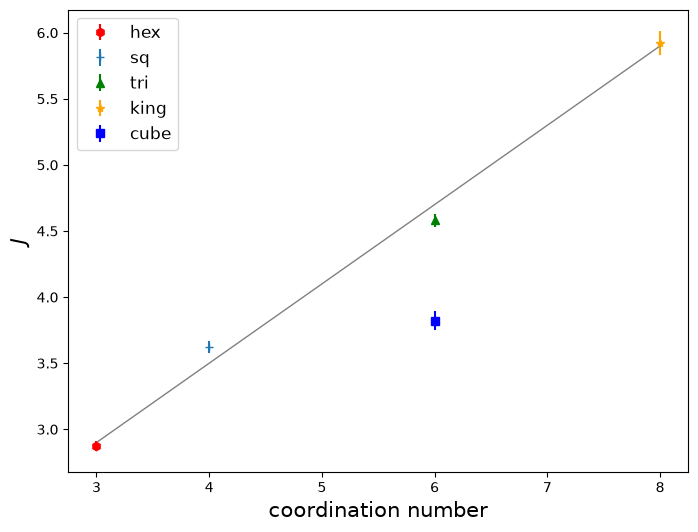

In [21]:
# ===== J Plot =====
plt.figure(figsize=(8,6))

# J_pair = (J, std[J])
for cardinality, J_pair, label, color, marker in zip(
    cardinality_list,
    J_mat,
    label_list,
    color_list,
    marker_list
):
    J, J_std = J_pair
    
    plt.errorbar(
        cardinality, J,
        yerr=J_std, 
        label=label,
        color=color,
        marker=marker,
        linestyle=''
    )

# Plot line
m = .6 
c = 1.2 - .1
x = np.linspace(min(cardinality_list), max(cardinality_list), num=1000)
y = m * x + c
plt.plot(x, y, color='gray', linewidth=1)

# Labels
plt.xlabel(
    "coordination number", fontsize=fontsize_label
)
plt.ylabel(
    "$J$", fontsize=fontsize_label
)
# plt.title(
#     "$J$ vs coordination number by lattice",
#     fontsize=fontsize_title
# )
plt.legend(fontsize=fontsize_legend)

plt.savefig(
    f"{outdirpath_fig}/J_vs_coordination_number_all_lattice.png",
    dpi=300,
    bbox_inches="tight"
)

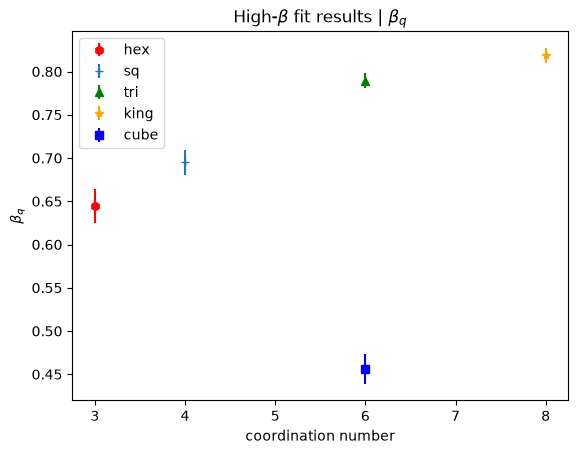

In [15]:
# ===== beta_q values =====
# beta_q_pair = (beta_q, std[beta_q])
for cardinality, beta_q_pair, label, color, marker in zip(
    cardinality_list,
    beta_q_mat,
    label_list,
    color_list,
    marker_list
):
    beta_q, beta_q_std = beta_q_pair
    
    plt.errorbar(
        cardinality, beta_q,
        yerr=beta_q_std,
        label=label,
        color=color,
        marker=marker,
        linestyle=''
    )

plt.xlabel("coordination number")
plt.ylabel("$\\beta_q$")
plt.title("High-$\\beta$ fit results | $\\beta_q$")
plt.legend()

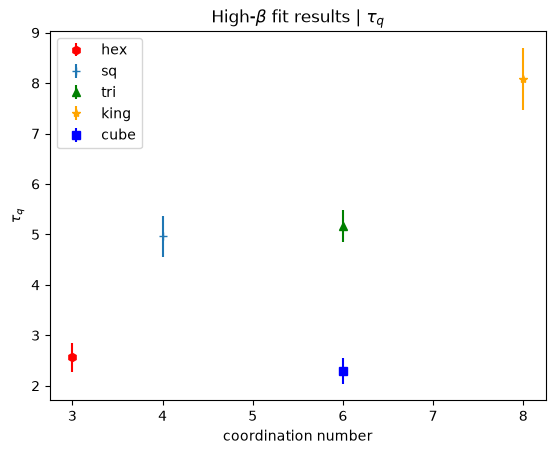

In [16]:
# ===== tau_q values =====
# tau_q_pair = (tau_q, std[tau_q])
for cardinality, tau_q_pair, label, color, marker in zip(
    cardinality_list,
    tau_q_mat,
    label_list,
    color_list,
    marker_list
):
    tau_q, tau_q_std = tau_q_pair
    
    plt.errorbar(
        cardinality, tau_q,
        yerr=tau_q_std,
        label=label,
        color=color,
        marker=marker,
        linestyle=''
    )

plt.xlabel("coordination number")
plt.ylabel("$\\tau_q$")
plt.title("High-$\\beta$ fit results | $\\tau_q$")
plt.legend()